In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')

import os
import tensorflow as tf
import keras
import cv2
import glob

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from tensorflow.keras import layers , models, optimizers

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.applications import ResNet50V2

# **Data Generator**

In [2]:
# specifing new image shape for resnet
img_shape = 224
batch_size = 64
train_data_path = './train/'
test_data_path = './test/'

In [3]:
train_preprocessor = ImageDataGenerator(
        rescale = 1 / 255.,
        rotation_range=10,
        zoom_range=0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,                                        
        fill_mode='nearest',
        validation_split=0.25) # set validation split
    


test_preprocessor = ImageDataGenerator(
    rescale = 1 / 255.,
)

train_data = train_preprocessor.flow_from_directory(
    train_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode='rgb',
    batch_size=batch_size,
    subset='training', 
)


val_data = train_preprocessor.flow_from_directory(
    train_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode='rgb',
    batch_size=batch_size,
    subset='validation',
) # set as validation data


test_data = test_preprocessor.flow_from_directory(
    test_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=False,
    batch_size=batch_size,
)

Found 21534 images belonging to 7 classes.
Found 7175 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# **Fine-Tuning ResNet50V2**

In [9]:
ResNet50V2 = tf.keras.applications.ResNet50V2(input_shape=(224, 224, 3),
                                               include_top= False,
                                               weights='imagenet'
                                               )


In [10]:
# Freezing all layers except last 50

ResNet50V2.trainable = True

for layer in ResNet50V2.layers[:-50]:
    layer.trainable = False

In [11]:
def Create_ResNet50V2_Model():

    model = Sequential([
                      ResNet50V2,
                      Dropout(0.25),
                      BatchNormalization(),
                      Flatten(),
                      Dense(64, activation='relu'),
                      BatchNormalization(),
                      Dropout(0.5),
                      Dense(7,activation='softmax')
                    ])
    return model

In [12]:
ResNet50V2_Model = Create_ResNet50V2_Model()

ResNet50V2_Model.summary()

ResNet50V2_Model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50v2 (Functional)     (None, 7, 7, 2048)        23564800  
                                                                 
 dropout (Dropout)           (None, 7, 7, 2048)        0         
                                                                 
 batch_normalization (Batch  (None, 7, 7, 2048)        8192      
 Normalization)                                                  
                                                                 
 flatten (Flatten)           (None, 100352)            0         
                                                                 
 dense (Dense)               (None, 64)                6422592   
                                                                 
 batch_normalization_1 (Bat  (None, 64)                256       
 chNormalization)                                       

**Specifying Callbacks**

In [14]:
# Create Callback Checkpoint
checkpoint_path = "ResNet50V2_Model.h5"

Checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True)

# Create Early Stopping Callback to monitor the accuracy
Early_Stopping = EarlyStopping(monitor = 'val_accuracy', patience = 7, restore_best_weights = True, verbose=1)

# Create ReduceLROnPlateau Callback to reduce overfitting by decreasing learning
Reducing_LR = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,
                                                  patience=2,
#                                                   min_lr=0.00005,
                                                  verbose=1)

callbacks = [Checkpoint, Early_Stopping, Reducing_LR]

steps_per_epoch = train_data.n // train_data.batch_size
validation_steps = val_data.n // val_data.batch_size

In [15]:
history = ResNet50V2_Model.fit(train_data,
                               validation_data = val_data , 
                               epochs=20, 
                               batch_size=batch_size,
                               callbacks = callbacks, 
                               steps_per_epoch=steps_per_epoch, 
                               validation_steps=validation_steps
                              )

Epoch 1/20
448/448 [==============================] - 959s 2s/step - loss: 1.5949 - accuracy: 0.4691 - val_loss: 1.6321 - val_accuracy: 0.5063 - lr: 0.0010
Epoch 2/20
448/448 [==============================] - 956s 2s/step - loss: 1.2409 - accuracy: 0.5528 - val_loss: 1.2114 - val_accuracy: 0.5545 - lr: 0.0010
Epoch 3/20
448/448 [==============================] - 957s 2s/step - loss: 1.1231 - accuracy: 0.5885 - val_loss: 1.0677 - val_accuracy: 0.6027 - lr: 0.0010
Epoch 4/20
448/448 [==============================] - 959s 2s/step - loss: 1.0614 - accuracy: 0.6149 - val_loss: 1.0693 - val_accuracy: 0.6074 - lr: 0.0010
Epoch 5/20
448/448 [==============================] - ETA: 0s - loss: 1.0274 - accuracy: 0.6246
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
448/448 [==============================] - 967s 2s/step - loss: 1.0274 - accuracy: 0.6246 - val_loss: 1.0838 - val_accuracy: 0.6131 - lr: 0.0010
Epoch 6/20
448/448 [==============================] - 958s

# **Evaluating ResNet50V2**

In [17]:
ResNet50V2_Score = ResNet50V2_Model.evaluate(test_data)

print("    Test Loss: {:.5f}".format(ResNet50V2_Score[0]))
print("Test Accuracy: {:.2f}%".format(ResNet50V2_Score[1] * 100))

113/113 [==============================] - 114s 1s/step - loss: 0.9179 - accuracy: 0.6818
    Test Loss: 0.91790
Test Accuracy: 68.18%


In [18]:
def plot_curves(history):

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(history.history["loss"]))

    plt.figure(figsize=(15,5))

    #plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label = "training_loss")
    plt.plot(epochs, val_loss, label = "val_loss")
    plt.title("Loss")
    plt.xlabel("epochs")
    plt.legend()

    #plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label = "training_accuracy")
    plt.plot(epochs, val_accuracy, label = "val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("epochs")
    plt.legend()

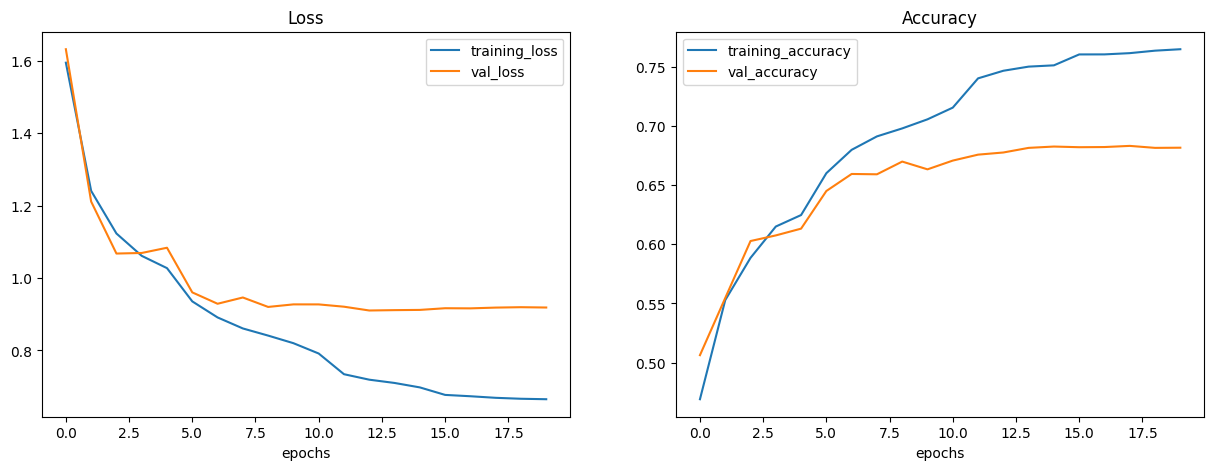

In [19]:
plot_curves(history)